In [1]:
# Import relevant libraries
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# importing training and tested sets
# leaving Validation set alone until very end of model validation

y_train_h5_path = r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\Springboard\Captsone 3 - Cancer Image Classification\Images\camelyonpatch_level_2_split_train_y.h5\camelyonpatch_level_2_split_train_y.h5"
X_train_h5_path = r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\Springboard\Captsone 3 - Cancer Image Classification\Images\camelyonpatch_level_2_split_train_x.h5\camelyonpatch_level_2_split_train_x.h5"
X_test_h5_path = r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\Springboard\Captsone 3 - Cancer Image Classification\Images\camelyonpatch_level_2_split_train_x.h5\camelyonpatch_level_2_split_train_x.h5"
y_test_h5_path = r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\Springboard\Captsone 3 - Cancer Image Classification\Images\camelyonpatch_level_2_split_train_y.h5\camelyonpatch_level_2_split_train_y.h5"

X_train_h5 = h5py.File(X_train_h5_path, 'r') # these are the images for training
y_train_h5 = h5py.File(y_train_h5_path, 'r') # this is a label for X train
X_test_h5 = h5py.File(X_test_h5_path, 'r') # these are the images for testing
y_test_h5 = h5py.File(y_test_h5_path, 'r') # these are the labels for the testing images

X_train = X_train_h5['x']
y_train = y_train_h5['y']
X_test = X_test_h5['x']
y_test = y_test_h5['y']

In [3]:
# checking shapes of trainings
print(f"X training (Images) Shape: {X_train.shape}")
print(f"y training (Labels) Shape: {y_train.shape}")
print(f"X training (Images) Data Type: {X_train.dtype}")

X training (Images) Shape: (262144, 96, 96, 3)
y training (Labels) Shape: (262144, 1, 1, 1)
X training (Images) Data Type: uint8


In [4]:
# checking shapes of tests
print(f"X test (Images) Shape: {X_test.shape}")
print(f"y test (Labels) Shape: {y_test.shape}")
print(f"X test (Images) Data Type: {X_test.dtype}")

X test (Images) Shape: (262144, 96, 96, 3)
y test (Labels) Shape: (262144, 1, 1, 1)
X test (Images) Data Type: uint8


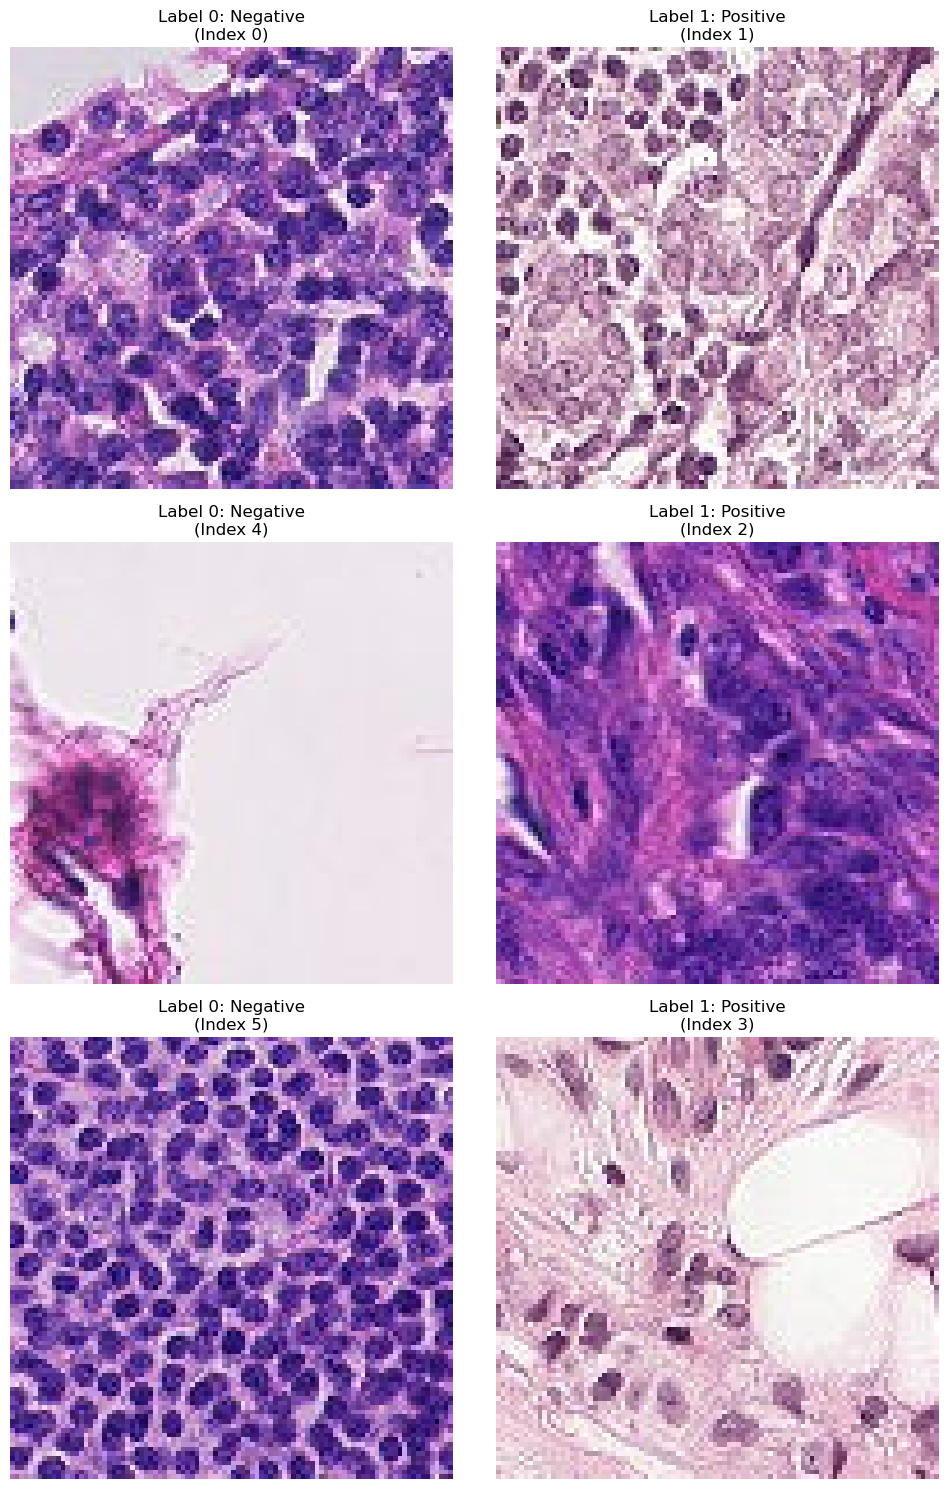

In [5]:
# these numbers are consistent with the description from the source.

# now need to see some images for sanity check

# start with setting up the labels
train_labels = np.squeeze(y_train)
test_labels = np.squeeze(y_test)

neg_train_index =  np.where(train_labels == 0)[0][:3] # only gets the three points that is negative
pos_train_index =  np.where(train_labels == 1)[0][:3] # only gets the three points that is negative

 # set fig size and set for 2 imgaes
fig, ax = plt.subplots(3,2,figsize = (10,15))

# make the plot; will loop through to check more images

for i in range(3):
    ax[i, 0].imshow(X_train[neg_train_index[i]])
    ax[i, 0].set_title(f"Label 0: Negative\n(Index {neg_train_index[i]})")
    ax[i, 0].axis('off')

    ax[i, 1].imshow(X_train[pos_train_index[i]])
    ax[i, 1].set_title(f"Label 1: Positive\n(Index {pos_train_index[i]})")
    ax[i, 1].axis('off')
    
plt.tight_layout()
plt.show()

In [6]:
# now to double check the quantity of cancer to non-cancer

print(f"Total Possitives in the Training dataset: {np.count_nonzero(train_labels)}")
print(f"Total Negatives in the Training dataset: {len(train_labels) - np.count_nonzero(train_labels)}")

Total Possitives in the Training dataset: 131072
Total Negatives in the Training dataset: 131072


In [7]:
# need to check the testing dataset

y_test_labels = np.squeeze(y_test)

print(f"Total Possitives in the Testing dataset: {np.count_nonzero(y_test_labels)}")
print(f"Total Negatives in the Testing dataset: {len(y_test_labels) - np.count_nonzero(y_test_labels)}")

Total Possitives in the Testing dataset: 131072
Total Negatives in the Testing dataset: 131072


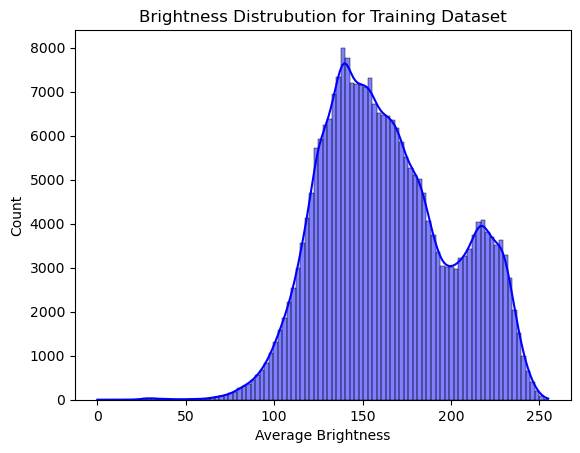

In [8]:
# not only are the testing and the training sets the same size, but the number of possitives and negatives are the same

# It looks like I will have a brightness issue
train_img_brightness = np.mean(X_train, axis=(1, 2, 3))

sns.histplot(train_img_brightness, bins=100, color='blue', kde=True)
plt.title('Brightness Distrubution for Training Dataset')
plt.xlabel('Average Brightness')
plt.show()

In [9]:
print(train_img_brightness[0:5])

[141.06676794 178.72840712 125.42473235 206.64178241 217.87384259]


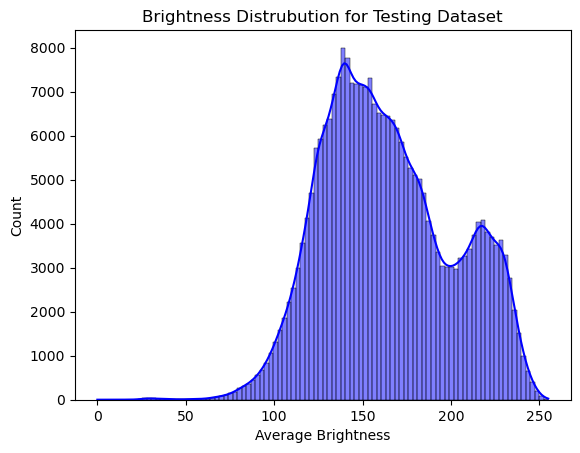

In [10]:
test_img_brightness = np.mean(X_test, axis=(1, 2, 3))

sns.histplot(test_img_brightness, bins=100, color='blue', kde=True)
plt.title('Brightness Distrubution for Testing Dataset')
plt.xlabel('Average Brightness')
plt.show()

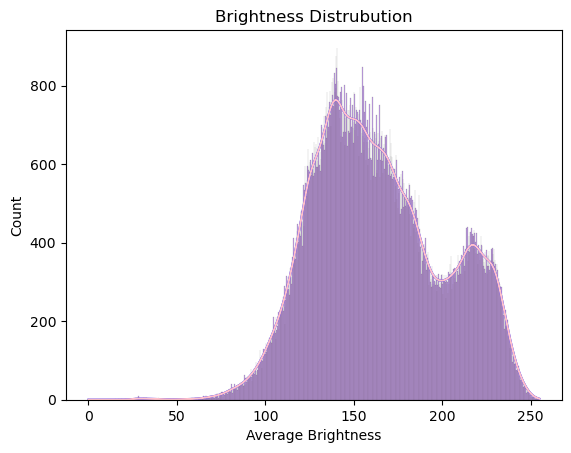

In [11]:
# concentrated bins just to get a better idea for the local min

sns.histplot(train_img_brightness, bins=1000, color='blue', kde=True)
sns.histplot(test_img_brightness, bins=1000, color='pink', kde=True)
plt.title('Brightness Distrubution')
plt.xlabel('Average Brightness')
plt.show()

The calculated threshold (valley) is: 199.57


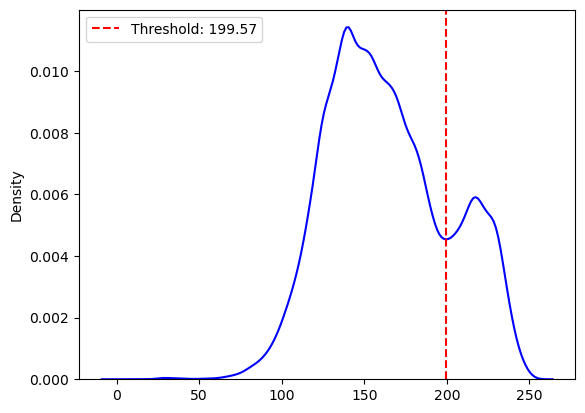

In [12]:
ax = sns.kdeplot(train_img_brightness, color="blue")
x_data, y_data = ax.get_lines()[0].get_data()


mask = (x_data > 120) & (x_data < 210)
min_idx = np.argmin(y_data[mask])
valley_x = x_data[mask][min_idx]

print(f"The calculated threshold (valley) is: {valley_x:.2f}")

# 3. Plot it with a vertical line to confirm
plt.axvline(valley_x, color='red', linestyle='--', label=f'Threshold: {valley_x:.2f}')
plt.legend()
plt.show()

The calculated threshold (valley) is: 199.57


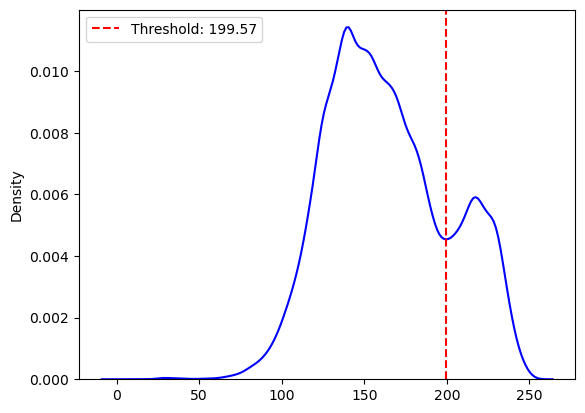

In [13]:
# going the same thing but with the test data

ax = sns.kdeplot(test_img_brightness, color="blue")
x_data, y_data = ax.get_lines()[0].get_data()

# 2. Find the local minimum between the two peaks
# We look for where the 'y' value is at its lowest in the middle range
# (You might need to adjust the range 100-200 based on your specific plot)
mask = (x_data > 120) & (x_data < 210)
min_idx = np.argmin(y_data[mask])
valley_x = x_data[mask][min_idx]

print(f"The calculated threshold (valley) is: {valley_x:.2f}")

# 3. Plot it with a vertical line to confirm
plt.axvline(valley_x, color='red', linestyle='--', label=f'Threshold: {valley_x:.2f}')
plt.legend()
plt.show()

In [14]:
with h5py.File(X_train_h5_path, 'r') as f:
    print(f"Your HDF5 keys are: {list(f.keys())}")

Your HDF5 keys are: ['x']


In [15]:
with h5py.File(X_train_h5_path, 'r') as f:
    for key in f.keys():
        print(f"Key: {key} | Shape: {f[key].shape}")

Key: x | Shape: (262144, 96, 96, 3)


In [16]:
train_labels.shape

(262144,)

In [17]:
train_img_brightness.shape

(262144,)

In [18]:
# Next I will want to turn the data into a pandas dataframe so I can start to get the data together. 

df_analysis = pd.DataFrame({
    'brightness': train_img_brightness.flatten(),
    'label': train_labels.flatten()
})

print(df_analysis.head())

   brightness  label
0  141.066768      0
1  178.728407      1
2  125.424732      1
3  206.641782      1
4  217.873843      0


In [19]:
threshold = 199.57

df_analysis['brightness_bin'] = df_analysis['brightness'].apply(lambda x: 'High' if x > threshold else 'Low')
df_analysis.head()

,brightness,label,brightness_bin
0,141.066768,0,Low
1,178.728407,1,Low
2,125.424732,1,Low
3,206.641782,1,High
4,217.873843,0,High


In [20]:
df_pivot = df_analysis.pivot_table(index='brightness_bin', 
                                   columns='label', 
                                   values='brightness', # Any column works here for a count
                                   aggfunc='count', 
                                   fill_value=0)
df_pivot

label,0,1
brightness_bin,,
High,43026,10486
Low,88046,120586


In [21]:
row_totals = df_pivot.sum(axis=1)
df_pivot['percent_cancer'] = (df_pivot[1] / row_totals) * 100
df_pivot

label,0,1,percent_cancer
brightness_bin,,,
High,43026,10486,19.595605
Low,88046,120586,57.798420


In [26]:
# there is a discrepancy in that there is a higher percent of images that are cancerous for the trainning set with the lower bin.

df_analysis_2 = pd.DataFrame({
    'brightness': test_img_brightness.flatten(),
    'label': test_labels.flatten()
})

print(df_analysis_2.head(20))

    brightness  label
0   141.066768      0
1   178.728407      1
2   125.424732      1
3   206.641782      1
4   217.873843      0
5   129.052337      0
6   114.217665      0
7   212.404369      1
8   137.975803      1
9   159.444047      1
10  151.284939      1
11  190.607530      1
12  129.299443      1
13  204.124132      0
14  157.631040      1
15  219.581706      1
16  196.489402      1
17  142.468316      1
18  139.627749      1
19  124.192274      1


In [23]:
df_analysis_2['brightness_bin'] = df_analysis_2['brightness'].apply(lambda x: 'High' if x > threshold else 'Low')
df_analysis_2.head()

,brightness,label,brightness_bin
0,141.066768,0,Low
1,178.728407,1,Low
2,125.424732,1,Low
3,206.641782,1,High
4,217.873843,0,High


In [24]:
df_pivot_2 = df_analysis_2.pivot_table(index='brightness_bin', 
                                   columns='label', 
                                   values='brightness', # Any column works here for a count
                                   aggfunc='count', 
                                   fill_value=0)
df_pivot_2

label,0,1
brightness_bin,,
High,43026,10486
Low,88046,120586


In [28]:
row_totals_2 = df_pivot_2.sum(axis=1)
df_pivot_2['percent_cancer'] = (df_pivot_2[1] / row_totals_2) * 100
df_pivot_2

label,0,1,percent_cancer
brightness_bin,,,
High,43026,10486,19.588434
Low,88046,120586,57.782417


In [29]:
# the train and test sets are the same at least
# now to look at the edges of the data

darkest_indices = df_analysis.sort_values('brightness').head(5).index
# Look at the brightest 5 images
brightest_indices = df_analysis.sort_values('brightness').tail(5).index


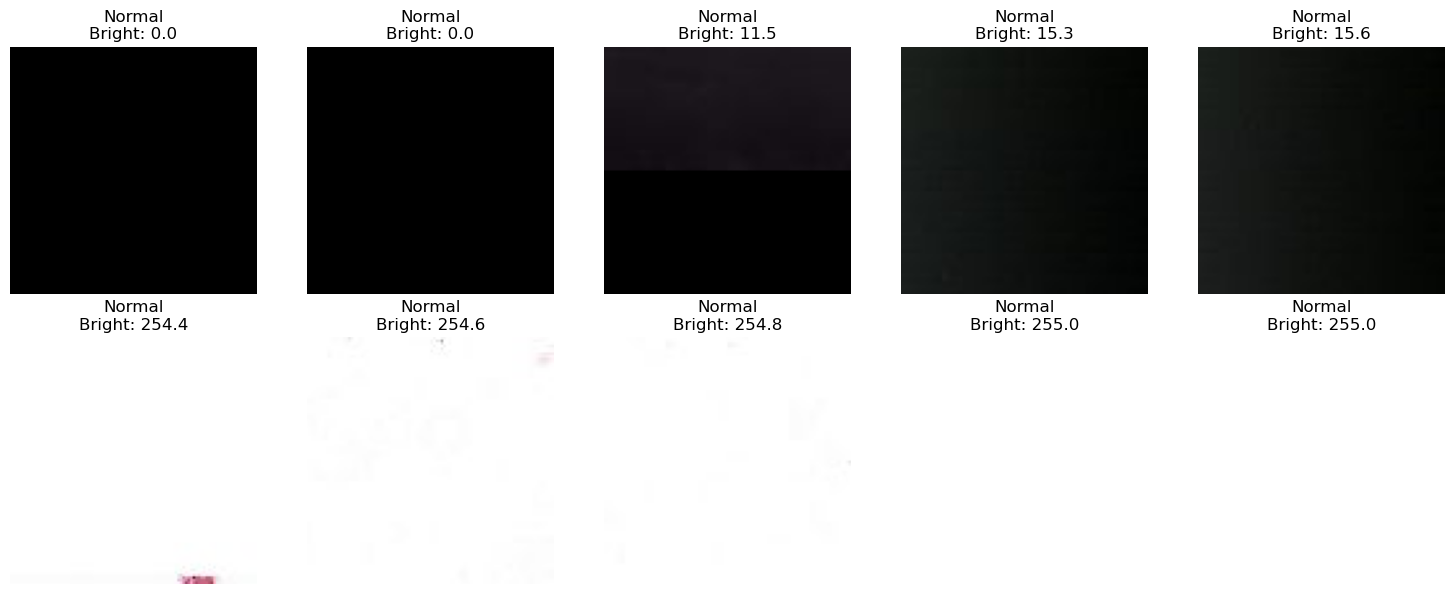

In [30]:
# Get indices for the 5 darkest and 5 brightest images
darkest_idx = df_analysis.sort_values('brightness').head(5).index
brightest_idx = df_analysis.sort_values('brightness').tail(5).index

# Combine them for one big plot
to_show = list(darkest_idx) + list(brightest_idx)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    
    # Add info to the title
    label = "Tumor" if train_labels[idx] == 1 else "Normal"
    brightness = df_analysis.loc[idx, 'brightness']
    plt.title(f"{label}\nBright: {brightness:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# Theses are probably not very helpful images
# It may be useful to remove the top brightest and 

lower_cutoff = df_analysis['brightness'].quantile(0.05)
upper_cutoff = df_analysis['brightness'].quantile(0.95)

print(f"Removing images darker than: {lower_cutoff:.2f}")
print(f"Removing images brighter than: {upper_cutoff:.2f}")

Removing images darker than: 110.44
Removing images brighter than: 228.67


In [32]:
keep_mask = (df_analysis['brightness'] >= lower_cutoff) & (df_analysis['brightness'] <= upper_cutoff)

# Apply the mask to your arrays
X_train_clean = X_train[keep_mask]
train_labels_clean = train_labels[keep_mask]

# Update your analysis dataframe if you want to keep it in sync
df_analysis_clean = df_analysis[keep_mask]

print(f"Original samples: {len(X_train)}")
print(f"Cleaned samples: {len(X_train_clean)}")

Original samples: 262144
Cleaned samples: 235928


In [33]:
lower_cutoff_test = df_analysis_2['brightness'].quantile(0.05)
upper_cutoff_test = df_analysis_2['brightness'].quantile(0.95)

print(f"Removing images darker than: {lower_cutoff:.2f}")
print(f"Removing images brighter than: {upper_cutoff:.2f}")

Removing images darker than: 110.44
Removing images brighter than: 228.67


In [35]:
keep_mask_test = (df_analysis_2['brightness'] >= lower_cutoff_test) & (df_analysis_2['brightness'] <= upper_cutoff_test)

# Apply the mask to your arrays
X_test_clean = X_test[keep_mask_test]
test_labels_clean = test_labels[keep_mask_test]

# Update your analysis dataframe if you want to keep it in sync
df_analysis_clean_test = df_analysis_2[keep_mask_test]

print(f"Original samples: {len(X_test)}")
print(f"Cleaned samples: {len(X_test_clean)}")

Original samples: 262144
Cleaned samples: 235928


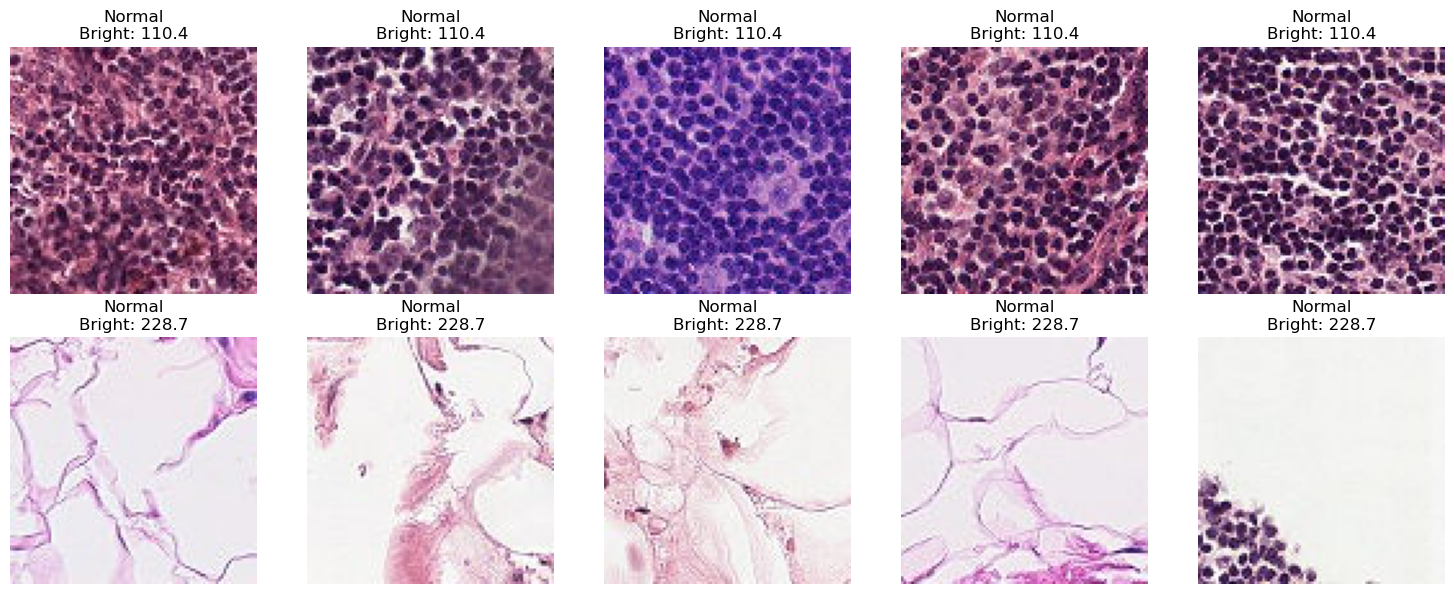

In [36]:
darkest_indices_2 = df_analysis_clean.sort_values('brightness').head(5).index
# Look at the brightest 5 images
brightest_indices_2 = df_analysis_clean.sort_values('brightness').tail(5).index

darkest_idx_2 = df_analysis_clean.sort_values('brightness').head(5).index
brightest_idx_2 = df_analysis_clean.sort_values('brightness').tail(5).index

# Combine them for one big plot
to_show_2 = list(darkest_idx_2) + list(brightest_idx_2)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(to_show_2):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    
    # Add info to the title
    label = "Tumor" if train_labels[idx] == 1 else "Normal"
    brightness = df_analysis.loc[idx, 'brightness']
    plt.title(f"{label}\nBright: {brightness:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

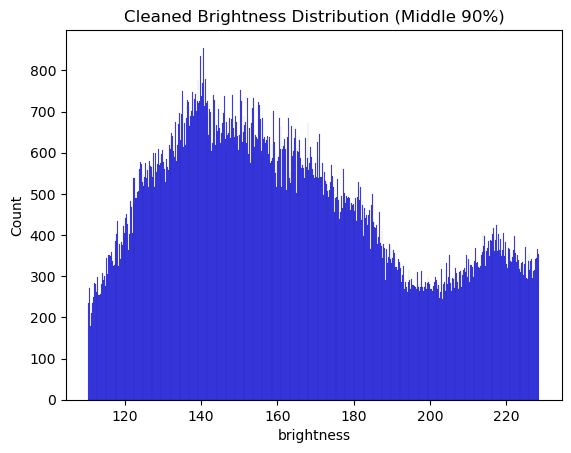

In [40]:
 # now to see the distributions again

sns.histplot(df_analysis_clean['brightness'], bins=500, color='blue')
plt.title("Cleaned Brightness Distribution (Middle 90%)")
plt.show()

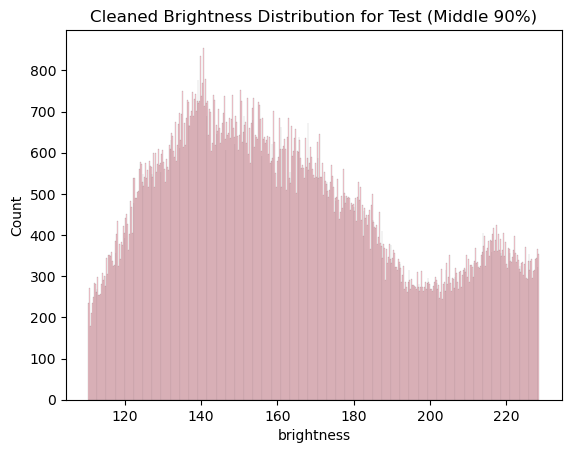

In [42]:
sns.histplot(df_analysis_clean_test['brightness'], bins=500, color='pink')
plt.title("Cleaned Brightness Distribution for Test (Middle 90%)")
plt.show()

In [43]:
# now to export

with h5py.File('PCam_cleaned_data.h5', 'w') as f:
    # Create the datasets (X and y)
    # Compression='gzip' helps save disk space!
    f.create_dataset('X_train_clean', data=X_train_clean, compression='gzip')
    f.create_dataset('y_train_clean', data=train_labels_clean, compression='gzip')

print("Export complete: PCam_cleaned_data.h5")

Export complete: PCam_cleaned_data.h5


In [44]:
with h5py.File('PCam_cleaned_test_data.h5', 'w') as f:
    # Create the datasets (X and y)
    # Compression='gzip' helps save disk space!
    f.create_dataset('X_test_clean', data=X_test_clean, compression='gzip')
    f.create_dataset('y_test_clean', data=test_labels_clean, compression='gzip')

print("Export complete: PCam_cleaned_test_data.h5")

Export complete: PCam_cleaned_test_data.h5


In [46]:
df_analysis_clean.to_csv('PCam_metadata_cleaned.csv', index=False)
df_analysis_clean_test.to_csv('PCam_metadata_test_cleaned.csv', index=False)